# investalyze: data log (findings + decisions)

A running, reproducible record of data quirks (characteristics of the data itself) and the decisions
they drive. Each entry says what the quirk is, why it exists, and that it is genuine data, not a mistake.
One markdown cell + one code cell per entry, grouped under the **Pending** and **Fixed** chapters,
newest on top within each. Committed with outputs.

Status legend: ✅ understood · 🔶 open question · ❓ to verify

Entry template: header `### <ticker / topic>: <one-line>  <status>`, then **What:**, **Why:** and,
once corrected via the cleaning package, **Fix:**.

## Index

Pending
- `^SPX` vs `^NDQ`: pre-1985 k-NN window ties, to verify ❓

Fixed
- `^NDQ` / `^NDX`: pre-launch `^NDX` history was a scaled proxy of `^NDQ`, deleted via cleaning ✅
- `^MRV` (Merval): index level spans ~8 orders of magnitude ✅

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from helpers import connect_readonly, load_ticker_rows

con = connect_readonly()

## Pending

Open quirks, to investigate.

### `^SPX` vs `^NDQ`: pre-1985 k-NN window ties, to verify ❓

**What**: the k-NN search that surfaced the `^NDX` issue also returned exact `sq_dist = 0.0` window
ties between `^SPX` and `^NDQ` around 1942-1943 and 1950-1951. Direct comparison of the two series:
the full pre-1985 overlap ratio is not constant (mean 1.33, std 0.38 over 12,585 shared days), and
splitting at Nasdaq Composite's real 1971-02-08 launch (`^NDQ` before that is itself unverified) gives
std 0.21 on both sides, nowhere near `^NDX`/`^NDQ`'s std < 0.001. A 200-day rolling std of the ratio
finds only two short, isolated flat stretches (~120 rows each, 1942-08-17 to 1943-01-18 and
1950-09-05 to 1951-02-05), 7+ years apart.

**Why**: no systemic proxy relationship shows up in the data the way it did for `^NDX`/`^NDQ`. The
two isolated flat stretches could be real market co-movement (WWII rally, Korean War-era bull run)
or something else entirely, not established either way.

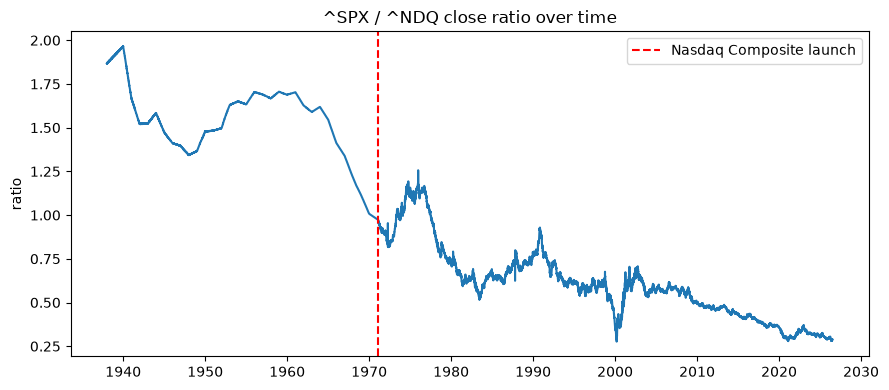

pre-1971  ratio: mean=1.5362 std=0.2093 (8885 rows)
post-1971 ratio: mean=0.6060 std=0.2092 (13965 rows)
locally flat stretches (200d rolling ratio std < 0.001): 2
       min        max  count
1942-08-17 1943-01-18    126
1950-09-05 1951-02-05    121


In [ ]:
spx = load_ticker_rows(con, 'market_data', '^SPX').sort_values('Date').reset_index(drop=True)
ndq = load_ticker_rows(con, 'market_data', '^NDQ').sort_values('Date').reset_index(drop=True)
merged = spx.merge(ndq, on='Date', suffixes=('_spx', '_ndq'))
merged['ratio'] = merged['C_spx'] / merged['C_ndq']

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(merged['Date'], merged['ratio'])
ax.axvline(pd.Timestamp('1971-02-08'), color='red', ls='--', label='Nasdaq Composite launch') # pyright: ignore[reportArgumentType]
ax.set_title('^SPX / ^NDQ close ratio over time')
ax.set_ylabel('ratio')
ax.legend()
plt.tight_layout()
plt.show()

pre = merged[merged['Date'] < '1971-02-08']
post = merged[merged['Date'] >= '1971-02-08']
print(f'pre-1971  ratio: mean={pre["ratio"].mean():.4f} std={pre["ratio"].std():.4f} ({len(pre)} rows)')
print(f'post-1971 ratio: mean={post["ratio"].mean():.4f} std={post["ratio"].std():.4f} ({len(post)} rows)')

roll_std = merged['ratio'].rolling(200, min_periods=200).std()
merged['flag'] = (roll_std < 0.001).fillna(False)
merged['block'] = (merged['flag'] != merged['flag'].shift()).cumsum()
blocks = merged[merged['flag']].groupby('block')['Date'].agg(['min', 'max', 'count'])
print(f'locally flat stretches (200d rolling ratio std < 0.001): {len(blocks)}')
print(blocks.to_string(index=False))

## Fixed

Resolved quirks: corrected via the cleaning package, or understood and kept as genuine data.

### `^NDQ` / `^NDX`: pre-launch `^NDX` history is a scaled proxy of `^NDQ` ✅ fixed

**What**: `^NDQ` and `^NDX` held a **constant price ratio** (~0.3979, std < 0.001) for their entire
shared history from 1938 up to 1985-10-02, then diverge to independent, uncorrelated real trading data
right around NASDAQ-100's actual October 1985 launch. These were **genuine rows in the DB**, not a
query bug: a scale-invariant encoding (`rebase_to_100`) collapses matching pre-1985 windows to
near-identical vectors, an exact `sq_dist = 0.0` tie in a k-NN search.

**Why**: likely vendor backfilling, before the real index existed its history was proxied with a
scaled substitute (a fixed ratio to another series) rather than left absent.

**Fix**: the 12,585 pre-launch `^NDX` rows (1938 to 1985-10-01) are deleted by the `[[delete_date_range]]`
entry in `cleaning.toml` (applied 2026-07-03). Ingest merge-upserts and never deletes, so a full reload
resurrects them: re-run `python -m investalyze.cleaning apply` afterwards. The cell below doubles as the
check: 0 pre-launch overlap rows = clean.

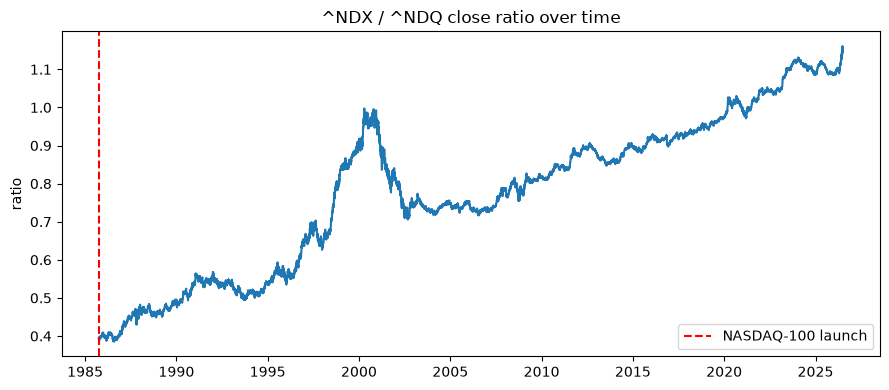

pre-launch  overlap: 0 rows (fix applied, clean)
post-launch ratio: mean=0.7758 std=0.202076 (10265 rows)


In [ ]:
a = load_ticker_rows(con, 'market_data', '^NDQ').sort_values('Date')
b = load_ticker_rows(con, 'market_data', '^NDX').sort_values('Date')
merged = a.merge(b, on='Date', suffixes=('_ndq', '_ndx'))
merged['ratio'] = merged['C_ndx'] / merged['C_ndq']

pre_launch = merged[merged['Date'] < '1985-10-02']
post_launch = merged[merged['Date'] >= '1985-10-02']

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(merged['Date'], merged['ratio'])
ax.axvline(pd.Timestamp('1985-10-02'), color='red', ls='--', label='NASDAQ-100 launch') # pyright: ignore[reportArgumentType]
ax.set_title('^NDX / ^NDQ close ratio over time')
ax.set_ylabel('ratio')
ax.legend()
plt.tight_layout()
plt.show()

if len(pre_launch) == 0:
    print('pre-launch  overlap: 0 rows (fix applied, clean)')
else:
    pre_mean, pre_std = pre_launch['ratio'].mean(), pre_launch['ratio'].std()
    print(f'pre-launch  ratio: mean={pre_mean:.4f} std={pre_std:.6f} ({len(pre_launch)} rows), run python -m investalyze.cleaning apply')
post_mean, post_std = post_launch['ratio'].mean(), post_launch['ratio'].std()
print(f'post-launch ratio: mean={post_mean:.4f} std={post_std:.6f} ({len(post_launch)} rows)')

### `^MRV` (Merval, Argentina): index level spans ~8 orders of magnitude ✅

**What**: `^MRV`, the Argentine Merval index, has an enormous **dynamic range**: its nominal level runs
from ~0.03 (1988) to ~3.3M (2026), roughly **8 orders of magnitude**. This is **genuine data, not a feed
glitch**.

**Why**: decades of Argentine **hyperinflation** plus several **currency redenominations** inflate the
index.

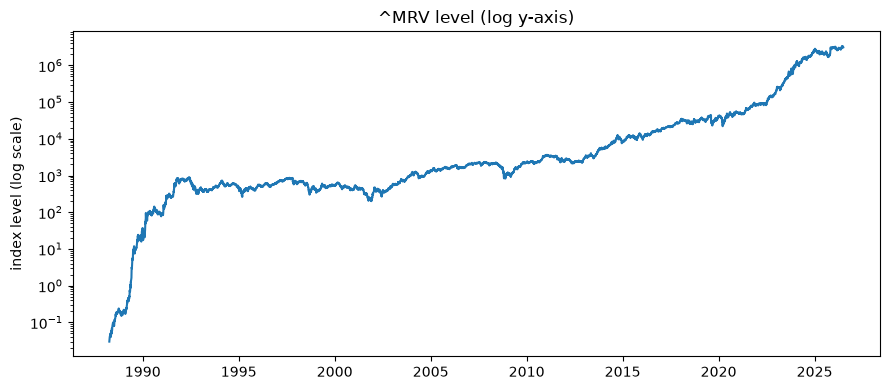

level range 0.03 to 3,353,008, span x111,766,925 (~8.0 orders of magnitude)


In [4]:
TICKER = '^MRV'

mrv = load_ticker_rows(con, 'market_data', TICKER).sort_values('Date')
price = mrv['C'].to_numpy()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mrv['Date'], price)
ax.set_yscale('log')
ax.set_title(f'{TICKER} level (log y-axis)')
ax.set_ylabel('index level (log scale)')
plt.tight_layout()
plt.show()

span = price.max() / price.min()
print(f'level range {price.min():g} to {price.max():,.0f}, span x{span:,.0f} (~{np.log10(span):.1f} orders of magnitude)')

---